In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

In [ ]:
df = pd.read_csv("/content/sample_data/customer_purchase_data.csv")

In [ ]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [ ]:
df.describe()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


In [ ]:
print(df.isnull().sum())

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


In [ ]:
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_3858/173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.corr()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
Age,1.000000,0.018998,0.012101,-0.046969,-0.014159,0.019733,-0.001972,0.019256,-0.253598
Gender,0.018998,1.000000,0.017676,0.001941,-0.023306,0.006987,0.039219,-0.046821,0.008856
AnnualIncome,0.012101,0.017676,1.000000,0.003408,0.025698,-0.003997,-0.037318,0.022385,0.191218
NumberOfPurchases,-0.046969,0.001941,0.003408,1.000000,0.017422,0.030379,0.052561,0.026414,0.219116
ProductCategory,-0.014159,-0.023306,0.025698,0.017422,1.000000,-0.006181,0.032945,0.022225,0.014349
TimeSpentOnWebsite,0.019733,0.006987,-0.003997,0.030379,-0.006181,1.000000,0.000948,0.005879,0.282127
LoyaltyProgram,-0.001972,0.039219,-0.037318,0.052561,0.032945,0.000948,1.000000,-0.049638,0.318059
DiscountsAvailed,0.019256,-0.046821,0.022385,0.026414,0.022225,0.005879,-0.049638,1.000000,0.296606
PurchaseStatus,-0.253598,0.008856,0.191218,0.219116,0.014349,0.282127,0.318059,0.296606,1.000000


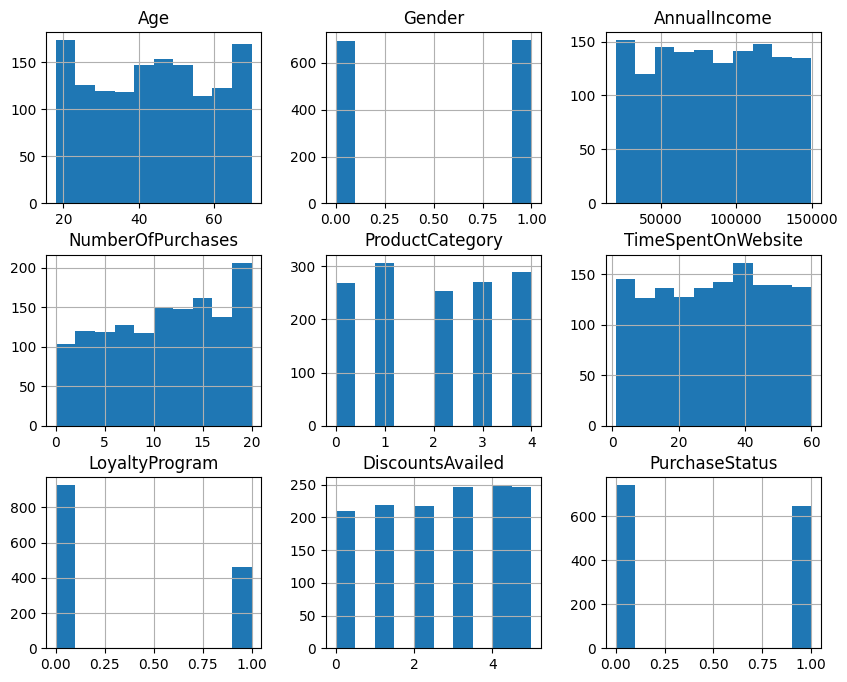

In [ ]:
df.hist(figsize=(10,8))
plt.show()

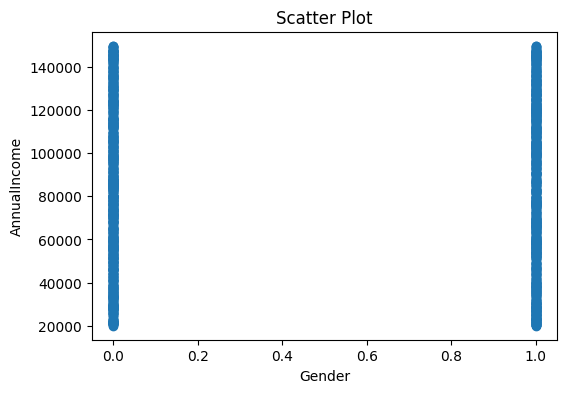

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df.iloc[:,1], df.iloc[:,2])
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[2])
plt.title("Scatter Plot")
plt.show()

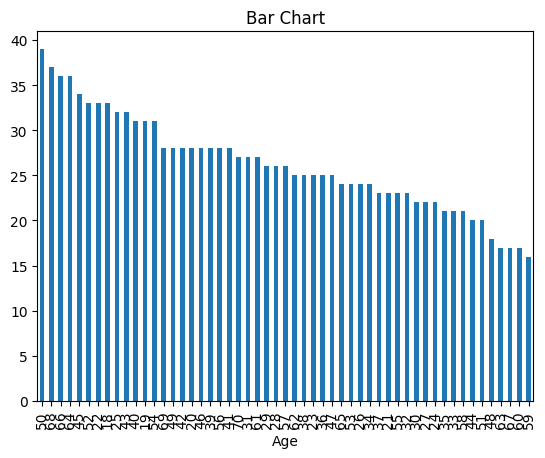

In [ ]:
df.iloc[:,0].value_counts().plot(kind="bar")
plt.title("Bar Chart")
plt.show()

In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.20,random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [ ]:
def evaluate(name,y_true,y_pred):

    print("\n",name)

    print("Accuracy :",accuracy_score(y_true,y_pred))

    print("Precision :",precision_score(y_true,y_pred,average="weighted"))

    print("Recall :",recall_score(y_true,y_pred,average="weighted"))

    print("F1 Score :",f1_score(y_true,y_pred,average="weighted"))

evaluate("Logistic Regression",y_test,lr_pred)
evaluate("KNN",y_test,knn_pred)
evaluate("Decision Tree",y_test,dt_pred)


 Logistic Regression
Accuracy : 0.8525179856115108
Precision : 0.8524595323741007
Recall : 0.8525179856115108
F1 Score : 0.8524776810645492

 KNN
Accuracy : 0.8273381294964028
Precision : 0.8279678357391868
Recall : 0.8273381294964028
F1 Score : 0.8274815884945883

 Decision Tree
Accuracy : 0.8561151079136691
Precision : 0.8561151079136691
Recall : 0.8561151079136691
F1 Score : 0.8561151079136691


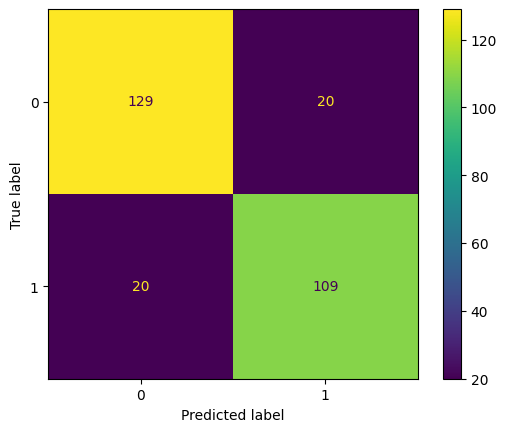

In [ ]:
cm = confusion_matrix(y_test,dt_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [ ]:
joblib.dump(dt,"best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
def predict_customer(data):

    data = scaler.transform([data])

    prediction = dt.predict(data)

    return prediction

In [ ]:
sample = X.iloc[0].tolist()

print("Prediction :",predict_customer(sample))

Prediction : [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(dt_pred)

Actual Values:
677     0
208     1
437     1
705     0
1369    1
       ..
1127    0
345     0
1364    1
1413    0
389     0
Name: PurchaseStatus, Length: 278, dtype: int64

Predicted Values:
[0 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 1
 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 1 0 0 1 0 0 1 1 1 1 0
 1 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1
 1 1 0 0 0 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0
 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0
 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0
 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 0 1 0 0]


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": dt_pred
})

print(results)

      Actual  Predicted
677        0          0
208        1          1
437        1          1
705        0          0
1369       1          0
...      ...        ...
1127       0          0
345        0          0
1364       1          1
1413       0          0
389        0          0

[278 rows x 2 columns]
